# Digital Signal Processing

# Example: Gesture

In [159]:
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.fft import fft, fftfreq

In [160]:
with open('gesture.circle.json') as fcircle, open('gesture.cross.json') as fcross:
    circle = json.load(fcircle)
    cross = json.load(fcross)

In [161]:
circle_trajectory = np.array(circle['trajectory'])
cross_trajectory = np.array(cross['trajectory'])

In [162]:
circle_x = circle_trajectory[:,0]
circle_y = circle_trajectory[:,1]
circle_t = circle_trajectory[:,2]
cross_x = cross_trajectory[:,0]
cross_y = cross_trajectory[:,1]
cross_t = cross_trajectory[:,2]

## Plotting the gestures

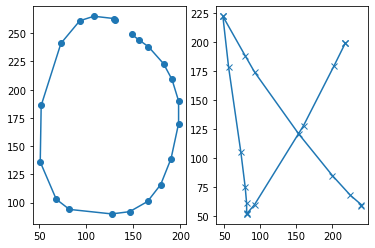

In [163]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(circle_x, circle_y, 'o-')
ax2.plot(cross_x, cross_y, 'x-')
plt.show()

# Plotting the gestures as signals

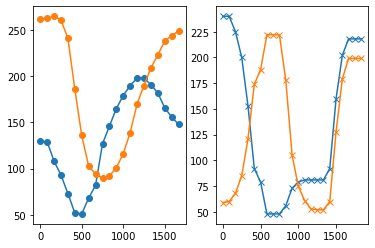

In [164]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(circle_t, circle_x, 'o-')
ax1.plot(circle_t, circle_y, 'o-')

ax2.plot(cross_t, cross_x, 'x-')
ax2.plot(cross_t, cross_y, 'x-')
plt.show()

## Spectral decomposition

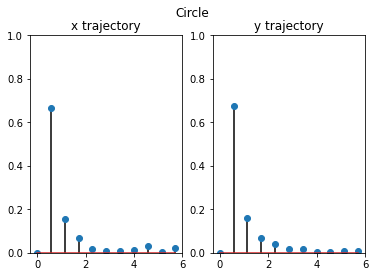

In [165]:
# Circle Gesture
N = len(circle_t)
SAMPLE_RATE = 12
end_idx = 11

f_x = fft(circle_x - np.mean(circle_x))[:end_idx]
f_x = f_x / np.sum(np.abs(f_x))

f_y = fft(circle_y - np.mean(circle_y))[:end_idx]
f_y = f_y / np.sum(np.abs(f_y))
f_dom = fftfreq(N, 1 / SAMPLE_RATE)[:end_idx]

end_idx = 11

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle("Circle")

ax1.stem(f_dom, np.abs(f_x), 'k-', use_line_collection=True)
ax1.set_ylim([0, 1])
ax1.set_title("x trajectory")

ax2.stem(f_dom, np.abs(f_y), 'k-', use_line_collection=True)
ax2.set_ylim([0, 1])
ax2.set_title("y trajectory")

plt.show()

f_circle = np.hstack((np.abs(f_x), np.abs(f_y)))


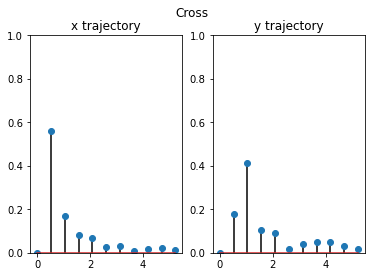

In [166]:
# Cross Gesture
N = len(cross_t)
SAMPLE_RATE = 12
end_idx = 11

f_x = fft(cross_x - np.mean(cross_x))[:end_idx]
f_x = f_x / np.sum(np.abs(f_x))
f_y = fft(cross_y - np.mean(cross_y))[:end_idx]
f_y = f_y / np.sum(np.abs(f_y))
f_dom = fftfreq(N, 1 / SAMPLE_RATE)[:end_idx]


fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle("Cross")
ax1.stem(f_dom, np.abs(f_x), 'k-', use_line_collection=True)
ax1.set_ylim([0, 1])
ax1.set_title("x trajectory")

ax2.stem(f_dom, np.abs(f_y), 'k-', use_line_collection=True)
ax2.set_ylim([0, 1])
ax2.set_title("y trajectory")

plt.show()

f_cross = np.hstack((np.abs(f_x), np.abs(f_y)))

## Template matching

In [182]:
with open('gesture.test.json') as ftest:
    test = json.load(ftest)
test_trajectory = np.array(test['trajectory'])

test_x = test_trajectory[:, 0]
test_y = test_trajectory[:, 1]
test_t = test_trajectory[:, 2]


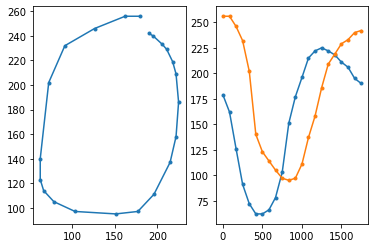

In [186]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(test_x, test_y, '.-')

ax2.plot(test_t, test_x, '.-')
ax2.plot(test_t, test_y, '.-')
plt.show()


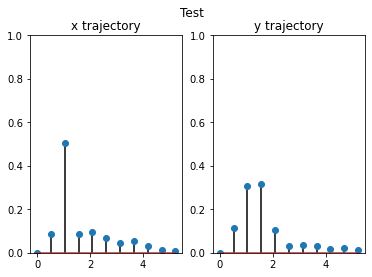

In [179]:

N = len(cross_t)
SAMPLE_RATE = 12
end_idx = 11

f_x = fft(test_x - np.mean(test_x))[:end_idx]
f_x = f_x / np.sum(np.abs(f_x))
f_y = fft(test_y - np.mean(test_y))[:end_idx]
f_y = f_y / np.sum(np.abs(f_y))
f_dom = fftfreq(N, 1 / SAMPLE_RATE)[:end_idx]

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle("Test")
ax1.stem(f_dom, np.abs(f_x), 'k-', use_line_collection=True)
ax1.set_ylim([0, 1])
ax1.set_title("x trajectory")

ax2.stem(f_dom, np.abs(f_y), 'k-', use_line_collection=True)
ax2.set_ylim([0, 1])
ax2.set_title("y trajectory")

plt.show()

f_test = np.hstack((np.abs(f_x), np.abs(f_y)))

In [180]:
np.sum(np.sqrt(np.power(f_test - f_circle, 2)))

2.304587875889981

In [181]:
np.sum(np.sqrt(np.power(f_test - f_cross, 2)))

1.4527600379161327